In [1]:
import numpy
import pandas
import os
import numpy
import scipy
import mod_utils as utils
import matplotlib.pyplot as plt
import os

In [7]:
math_vars = {
    'high_rho': 3,
    'low_rho' : 1,
    'high_visc' : 0.001, #dynamic
    'low_visc' : 0.001,#0.0005,
    'wavelength' : 1,
    'grev': 1,
    'x_L' : 1,
    'y_L' : 4,
    'delta_h': 0.05,
    'timestep': 0.0035,
    'time_end': 8,
    'maxWidthCutOff': 0.01,
    'surface_tension': 1e-05
}

model = utils.dynamic_model(math_vars)

model.set_nondim_consts(
    ref_l = 'x_L',
    ref_rho = 'high_rho',
    ref_grev = 'grev',
    ref_visc = 'low_visc',
    ref_visc_kin = lambda ref_visc, ref_rho: ref_visc/ref_rho, 
    ref_u = lambda ref_grev, ref_l: numpy.sqrt(ref_grev*ref_l),
    ref_surface_tension = lambda ref_l, ref_rho, ref_u, surface_tension: ref_rho*ref_l*numpy.pow(ref_u, 2)*surface_tension
)

#{} means it's in the mod_utils as a seperate class method, otherwise lambda
model.calculate_nondim_nums(
    atwood = {},
    reynolds = {},
    froude = {},
    #grashof = {},
    grash2 = lambda high_rho, low_rho, ref_grev, ref_l, ref_visc, ref_rho: ((high_rho - low_rho)/(high_rho + low_rho))*ref_grev*numpy.pow(ref_l, 3)/numpy.pow((ref_visc/ref_rho), 2),#Aglam^3/kin_visc^2
    #ren2 = lambda ref_grev, ref_l, ref_rho, ref_visc: (numpy.sqrt(numpy.pow(ref_l,3)*ref_grev)*ref_rho)/ref_visc
    weber = lambda ref_rho, ref_l, ref_u, ref_surface_tension: ref_rho*ref_l*(numpy.pow(ref_u, 2))/ref_surface_tension,
    eotvos = lambda high_rho, low_rho, ref_grev, ref_l, ref_surface_tension: (high_rho - low_rho)*ref_grev*numpy.pow(ref_l, 2)/ref_surface_tension
    )

{'atwood_num': 0.5, 'reynolds_num': np.float64(3000.0), 'froude_num': np.float64(1.0), 'grash2_num': np.float64(4500000.0), 'weber_num': np.float64(99999.99999999999), 'eotvos_num': np.float64(66666.66666666666)}


In [ ]:

#edit as required
name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'v_x': "Velocity[i] (m/s)",
    'v_y': "Velocity[j] (m/s)",
    'rel_v_x': "Relative Velocity[i] (m/s)",
    "rel_v_y": "Relative Velocity[j] (m/s)",
    'volFrac_high': "Volume Fraction of high_rho",
    'volFrac_low': "Volume Fraction of low_rho",
    'min_mixWidth': "minMixWidthEval",
    'max_mixWidth': "maxMixWidthEval",
    'massFlux': "Report: massImbalance_highRho (kg)",
    'mean_rho': "Density (kg/m^3)"
}

dir = r'/home/yy310050/Desktop/rayleigh-taylor/simulations/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.007'
name = 'isosurface_table_'
name_append = '.csv'

#if reference time is different from the reference time initially set
ref_t = lambda atwood_num: numpy.sqrt(atwood_num)

model.load_solution_data(dir, name, name_append, name_vars, ref_t= ref_t)

{'atwood_num': 0.5, 'reynolds_num': np.float64(300.0), 'froude_num': np.float64(1.0), 'grashof_num': np.float64(11.25), 'grash2_num': np.float64(44999.99999999999), 'weber_num': np.float64(99999.99999999999), 'eotvos_num': np.float64(66666.66666666666)}
comparing file params with model params with params.ini 

delta_h - 0.007 , 0.05
high_rho - 3 , 3
low_rho - 1 , 1
surface_tension - 1e-05 , 1e-05
time_end - 6.5 , 8
timestep - 0.0035 , 0.0035


In [21]:
model.calculate_stuff()

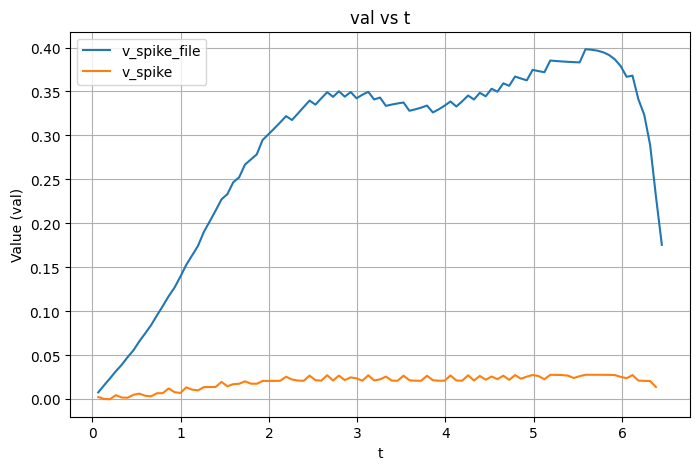

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(model.params['timesteps'], numpy.abs(model.analysis_data['v_spike_file']), label='v_spike_file')
plt.plot(model.params['timesteps'][:-1], model.analysis_data['v_spike'], label='v_spike')
plt.xlabel("t")
plt.ylabel("Value (val)")
plt.title("val vs t")
plt.legend()
plt.grid(True)
plt.show()

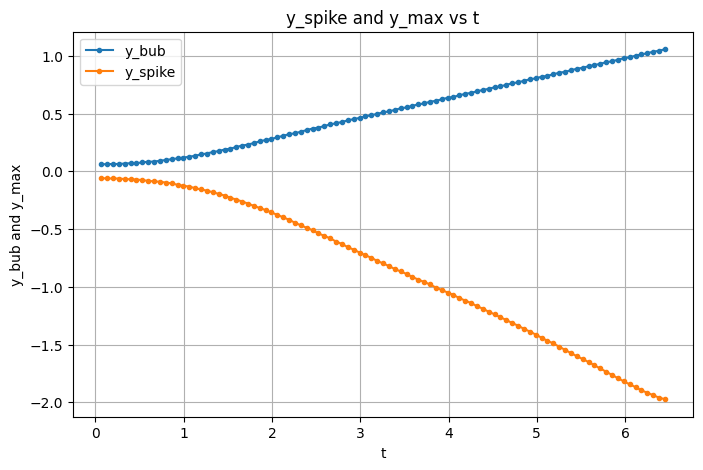

In [25]:
# Plot y_max and y_min on the same graph
plt.figure(figsize=(8, 5))
plt.plot(model.params['timesteps'], model.analysis_data['y_bub'], label='y_bub', marker = ".")
plt.plot(model.params['timesteps'], model.analysis_data['y_spike'], label='y_spike', marker = ".")
#plt.plot(nondimtime, y_s, label='y_min', marker = '.')
plt.xlabel("t")
plt.ylabel("y_bub and y_max")
plt.title("y_spike and y_max vs t")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#1010, 1414, 1818, 2222, 2626, 3030